<a href="https://colab.research.google.com/github/Daesoon0123/ai_agent_test/blob/main/01_context_limit_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 예제 01. 컨텍스트 한계에 직접 부딪히기 · Example 01 — Running Into the Context Limit Yourself

전산실험 2 · AI Agent 만들기 · **4주차** · 예상 소요 30분
Computational Experiments 2 · Building AI Agents · **Week 4** · about 30 minutes

## 목표 · Objectives
- 대화를 매번 다시 보낸다는 사실의 **비용**을 측정한다
- 누적 토큰이 턴 수에 대해 어떻게 늘어나는지 확인한다
- 토큰 근사값과 서버의 실제 `usage` 를 비교한다
- 한계를 넘겼을 때 무슨 일이 일어나는지 본다

> **EN**
> - Measure **the cost** of the fact that we resend the conversation every turn
> - See how the cumulative token count grows with the number of turns
> - Compare the token approximation against the server's actual `usage`
> - Watch what happens when you cross the limit

### 준비 — 공용 모듈과 데이터 만들기 / Setup — write the shared modules and data

이 수업 저장소에는 노트북(`.ipynb`)만 둡니다. 그래서 실습에 필요한 공용 모듈과
데이터를 **아래 셀들이 직접 파일로 만들어 냅니다.** 내려받지 않으므로 네트워크가
느려도, 저장소가 비공개로 바뀌어도 그대로 동작합니다.

아래 셀을 **위에서부터 차례로 한 번씩** 실행한 뒤 다음으로 넘어가세요.
내용을 지금 읽을 필요는 없습니다. 만들어진 `.py` 파일은 왼쪽 파일 탐색기에서
언제든 열어 볼 수 있습니다.

The course repository contains notebooks only. The cells below **write the shared
modules and data files themselves** instead of downloading them. Run them once,
top to bottom, then continue. You do not need to read them now — the generated
`.py` files can be opened from the file browser on the left.

In [ ]:
%%writefile kmu_llm.py
"""전산실험2 - AI Agent 만들기 : 공용 LLM 래퍼.

계명대 통계학과 서버와 Google Gemini를 같은 방식으로 호출한다.
둘 다 OpenAI 호환 API를 제공하므로 openai SDK 하나로 통일하고
base_url 과 model 만 바꾼다.

EN — Shared LLM wrapper for "Computational Experiments 2: Building AI Agents".
Calls the Keimyung Statistics department server and Google Gemini the same way.
Both expose an OpenAI-compatible API, so we use the single openai SDK and only
swap `base_url` and `model`.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 이 저장소는 공개(public)이므로 **학과 서버 주소와 API 키를 코드에 적지
 않는다.** 둘 다 수업시간에 공개하고, 각자 Colab Secrets 에 저장해서 쓴다.

     KMU_BASE_URL  = 수업시간에 공개  (예: https://.../v1)
     KMU_API_KEY   = 수업시간에 공개

 왼쪽 열쇠 아이콘(🔑) → 새 secret → 노트북 액세스 토글 켜기

 EN — This repository is PUBLIC, so never write the department server URL or
 the API key in code. Both are announced in class; store them in Colab Secrets.
     Key icon (🔑) on the left → new secret → turn on notebook access
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

사용 예 · Example:
    from kmu_llm import LLM, ask, check_server

    check_server()                       # 서버가 살아 있는지 먼저 확인
                                         # Check the server is alive first
    print(ask("표준편차를 한 문장으로 설명해줘"))

    llm = LLM(provider="gemini")         # 백업 경로 / Fallback route
    print(llm.chat([{"role": "user", "content": "안녕"}]))
"""

from __future__ import annotations

import os
import time
from typing import Any, Iterator

__all__ = [
    "KMU_MODEL",
    "GEMINI_BASE_URL",
    "GEMINI_MODEL",
    "PROVIDERS",
    "LLM",
    "ask",
    "get_secret",
    "get_key",
    "get_base_url",
    "check_server",
]

# --------------------------------------------------------------------------
# 서버 설정 / Server configuration
# --------------------------------------------------------------------------
# 학과 서버 주소는 여기에 적지 않는다. Colab Secrets 의 KMU_BASE_URL 에서 읽는다.
# 모델 태그는 공개해도 무방하므로 상수로 둔다.
# EN — The department server URL is never written here; it is read from the
#      Colab secret KMU_BASE_URL. The model tag is harmless to publish, so it
#      stays a constant.
KMU_MODEL = os.environ.get("KMU_MODEL", "gemma4")

# 백업 경로. Google AI Studio 에서 무료 키를 발급받아 쓴다. (공개 주소)
# EN — Fallback route. Get a free key from Google AI Studio. (public URL)
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GEMINI_MODEL = "gemini-2.0-flash"

PROVIDERS: dict[str, dict[str, Any]] = {
    "kmu": {
        "base_url": None,  # 실행 시점에 Secrets 에서 읽는다 / read from Secrets at runtime
        "base_url_key": "KMU_BASE_URL",
        "model": KMU_MODEL,
        "key_name": "KMU_API_KEY",
        "label": "계명대 학과 서버",
    },
    "gemini": {
        "base_url": GEMINI_BASE_URL,
        "base_url_key": None,
        "model": GEMINI_MODEL,
        "key_name": "GEMINI_API_KEY",
        "label": "Google Gemini (백업)",
    },
}


# --------------------------------------------------------------------------
# 비밀정보 가져오기 / Loading secrets
# --------------------------------------------------------------------------
def get_secret(name: str, *, prompt: bool = True, secret: bool = True) -> str:
    """설정값을 안전한 순서로 찾는다.

    1) Colab Secrets (왼쪽 열쇠 아이콘)  2) 환경변수  3) 직접 입력

    값을 코드에 적지 않는 것이 핵심이다. 노트북이나 모듈을 GitHub 에 올리는
    순간 코드에 적힌 값은 전 세계에 공개된다. API 키뿐 아니라 **내부 서버
    주소도** 마찬가지다.

    EN — Look up a configuration value in a safe order:
    1) Colab Secrets (key icon on the left)  2) environment variable  3) prompt.
    The point is to keep the value out of the source. The moment a notebook or
    module is pushed to GitHub, anything written in the code is world-readable —
    the internal server URL just as much as the API key.

    Parameters
    ----------
    secret : True 면 입력을 화면에 표시하지 않는다(getpass).
             주소처럼 오타 확인이 중요한 값은 False 로 준다.
             EN — True hides the typed value (getpass). Pass False for values
             like a URL where you need to see typos.
    """
    # 1) Colab Secrets
    try:
        from google.colab import userdata  # type: ignore

        value = userdata.get(name)
        if value:
            return value.strip()
    except Exception:
        pass

    # 2) 환경변수 / environment variable
    value = os.environ.get(name)
    if value:
        return value.strip()

    # 3) 직접 입력 / type it in
    if not prompt:
        raise RuntimeError(
            f"'{name}' 를 찾을 수 없습니다.\n"
            f"  Colab 왼쪽 열쇠 아이콘(🔑) → 새 secret → 이름 '{name}'\n"
            f"  값은 수업시간에 공개합니다. 노트북 액세스 토글도 켜세요."
        )

    print(f"[{name}] 를 찾지 못했습니다. 직접 입력해 주세요.")
    print(f"   (Colab Secrets 에 '{name}' 로 저장해 두면 다시 묻지 않습니다)")

    if secret:
        import getpass

        value = getpass.getpass(f"{name}: ").strip()
    else:
        value = input(f"{name}: ").strip()

    if not value:
        raise RuntimeError(f"'{name}' 에 빈 값이 입력되었습니다.")
    os.environ[name] = value  # 같은 런타임 안에서는 다시 묻지 않는다 / ask only once per runtime
    return value


def get_key(key_name: str = "KMU_API_KEY", *, prompt: bool = True) -> str:
    """API 키를 가져온다. (get_secret 의 별칭 — 1주차 이름 유지)

    EN — Fetch the API key. Alias of get_secret, kept under the week-1 name.
    """
    return get_secret(key_name, prompt=prompt, secret=True)


def get_base_url(provider: str = "kmu", *, prompt: bool = True) -> str:
    """서버 주소를 가져온다. 끝의 '/' 는 떼고 돌려준다.

    학과 서버 주소는 저장소에 적지 않으므로 Secrets 에서 읽는다.
    '/chat/completions' 까지 붙여서 저장한 경우도 알아서 잘라낸다.

    EN — Return the server URL with any trailing '/' removed. The department
    URL is never stored in the repository, so it comes from Secrets. If you
    saved the full '/chat/completions' path, it is trimmed for you.
    """
    conf = PROVIDERS[provider]

    if conf["base_url"]:
        return str(conf["base_url"]).rstrip("/")

    url = get_secret(conf["base_url_key"], prompt=prompt, secret=False).rstrip("/")

    # openai SDK 는 base_url 뒤에 /chat/completions 를 스스로 붙인다.
    # 주소를 통째로 저장한 경우를 대비해 정리해 준다.
    # EN — The openai SDK appends /chat/completions itself, so strip it here in
    #      case the whole path was saved as the secret.
    for suffix in ("/chat/completions", "/completions"):
        if url.endswith(suffix):
            url = url[: -len(suffix)]

    conf["base_url"] = url  # 같은 세션에서는 재사용 / reuse within the session
    return url


# --------------------------------------------------------------------------
# LLM 클라이언트 / LLM client
# --------------------------------------------------------------------------
class LLM:
    """OpenAI 호환 서버를 감싼 얇은 클라이언트.

    EN — A thin client wrapping any OpenAI-compatible server.

    Parameters
    ----------
    provider : "kmu" | "gemini"
        어느 서버를 쓸지. 기본은 학과 서버.
        EN — Which server to use. Defaults to the department server.
    model, base_url, api_key :
        직접 지정하면 기본값을 덮어쓴다. (보통 지정하지 않는다)
        EN — Override the defaults. You normally leave these alone.
    """

    def __init__(
        self,
        provider: str = "kmu",
        model: str | None = None,
        base_url: str | None = None,
        api_key: str | None = None,
        timeout: float = 120.0,
    ) -> None:
        if provider not in PROVIDERS:
            raise ValueError(
                f"알 수 없는 provider: {provider!r}. 가능한 값: {list(PROVIDERS)}"
            )
        conf = PROVIDERS[provider]

        self.provider = provider
        self.label = conf["label"]
        self.model = model or conf["model"]
        self.base_url = base_url or get_base_url(provider)
        self.api_key = api_key or get_key(conf["key_name"])

        try:
            from openai import OpenAI
        except ImportError as exc:  # pragma: no cover
            raise ImportError(
                "openai 패키지가 필요합니다.  !pip install -q openai"
            ) from exc

        self.client = OpenAI(
            api_key=self.api_key, base_url=self.base_url, timeout=timeout
        )

    def __repr__(self) -> str:
        # 주소는 출력하지 않는다. 화면 공유·스크린샷으로 새어나가기 쉽다.
        # EN — Never print the URL; screen shares and screenshots leak it easily.
        return f"LLM(provider={self.provider!r}, model={self.model!r})"

    # -- 기본 호출 / Core calls -------------------------------------------
    def raw(self, messages: list[dict[str, str]], **kw: Any):
        """응답 객체 전체를 그대로 돌려준다. usage(토큰 수) 확인용.

        EN — Return the full response object, so you can inspect `usage`
        (token counts).
        """
        params: dict[str, Any] = {
            "model": self.model,
            "messages": messages,
            "temperature": 0.7,
            "max_tokens": 1024,
        }
        params.update(kw)
        return self.client.chat.completions.create(**params)

    def chat(self, messages: list[dict[str, str]], **kw: Any) -> str:
        """대화 메시지를 보내고 응답 '텍스트'만 돌려준다.

        EN — Send the message list and return only the response text.
        """
        response = self.raw(messages, **kw)
        content = response.choices[0].message.content
        return (content or "").strip()

    def stream(self, messages: list[dict[str, str]], **kw: Any) -> Iterator[str]:
        """응답을 조각(chunk) 단위로 흘려보낸다. 타이핑되는 효과.

        EN — Yield the response chunk by chunk, giving the typing effect.
        """
        kw["stream"] = True
        for chunk in self.raw(messages, **kw):
            if not chunk.choices:
                continue
            piece = chunk.choices[0].delta.content
            if piece:
                yield piece

    # -- 편의 메서드 / Convenience methods ---------------------------------
    def ask(self, prompt: str, system: str | None = None, **kw: Any) -> str:
        """한 번짜리 질문. messages 를 매번 만들기 번거로울 때 쓴다.

        EN — A one-shot question, for when building `messages` by hand is
        tedious.
        """
        messages: list[dict[str, str]] = []
        if system:
            messages.append({"role": "system", "content": system})
        messages.append({"role": "user", "content": prompt})
        return self.chat(messages, **kw)

    def ask_retry(
        self,
        prompt: str,
        system: str | None = None,
        *,
        n_retry: int = 3,
        wait: float = 2.0,
        **kw: Any,
    ) -> str:
        """일시적인 네트워크·서버 오류를 재시도한다.

        30회 반복 실험처럼 호출이 많은 실습에서 한 번의 실패로 전체가
        멈추지 않도록 하기 위한 것이다.

        EN — Retry transient network/server errors, so that a lab with many
        calls (a 30-repetition experiment, say) does not die on one failure.
        """
        last_error: Exception | None = None
        for attempt in range(1, n_retry + 1):
            try:
                return self.ask(prompt, system, **kw)
            except Exception as exc:  # 네트워크·서버 오류 전반 / any network or server error
                last_error = exc
                if attempt < n_retry:
                    print(f"   [재시도 {attempt}/{n_retry - 1}] {type(exc).__name__}")
                    time.sleep(wait * attempt)  # 점점 더 오래 기다린다 / back off progressively
        raise RuntimeError(f"{n_retry}회 시도 모두 실패했습니다.") from last_error

    def count_tokens(self, messages: list[dict[str, str]]) -> int:
        """입력 토큰 수를 서버에 물어본다. 출력은 1토큰으로 잘라 낭비를 줄인다.

        EN — Ask the server how many input tokens the messages use; the output
        is capped at 1 token to avoid waste.
        """
        return self.raw(messages, max_tokens=1).usage.prompt_tokens


# --------------------------------------------------------------------------
# 모듈 수준 편의 함수 / Module-level convenience functions
# --------------------------------------------------------------------------
_default_llm: LLM | None = None


def ask(
    prompt: str, system: str | None = None, *, provider: str = "kmu", **kw: Any
) -> str:
    """가장 간단한 한 줄 호출.  ask("안녕") -> "안녕하세요..."

    내부적으로 LLM 객체를 한 번만 만들어 재사용한다.

    EN — The simplest one-line call. Internally it builds one LLM object and
    reuses it.
    """
    global _default_llm
    if _default_llm is None or _default_llm.provider != provider:
        _default_llm = LLM(provider=provider)
    return _default_llm.ask(prompt, system, **kw)


# --------------------------------------------------------------------------
# 서버 진단 / Server diagnostics
# --------------------------------------------------------------------------
def check_server(provider: str = "kmu", base_url: str | None = None) -> dict[str, Any]:
    """서버가 살아 있는지, 어떤 모델이 올라가 있는지 확인한다.

    수업 첫 실습. 실패하면 무엇을 확인해야 하는지 함께 출력한다.

    EN — Check that the server is alive and see which models it serves. This is
    the very first lab of the course; on failure it prints what to check.

    Returns
    -------
    dict : {"ok": bool, "models": list[str], "error": str | None}
    """
    import requests

    conf = PROVIDERS[provider]
    base_url = (base_url or get_base_url(provider)).rstrip("/")
    api_key = get_key(conf["key_name"])

    # 주소 전체를 출력하지 않는다. 호스트만 가려서 보여준다.
    # EN — Never print the full URL; show the host masked.
    print(f"조회 중: GET {_mask_url(base_url)}/models")

    try:
        response = requests.get(
            f"{base_url}/models",
            headers={"Authorization": f"Bearer {api_key}"},
            timeout=15,
        )
    except Exception as exc:
        print(f"\n[실패] 서버에 연결하지 못했습니다: {type(exc).__name__}")
        _print_troubleshooting()
        return {"ok": False, "models": [], "error": str(exc)}

    if response.status_code != 200:
        print(f"\n[실패] HTTP {response.status_code}")
        print(f"   응답: {response.text[:300]}")
        if response.status_code in (401, 403):
            print("   -> API 키가 잘못되었거나 만료되었을 가능성이 높습니다.")
        elif response.status_code == 404:
            print("   -> KMU_BASE_URL 이 '/v1' 로 끝나는지 확인하세요.")
        return {"ok": False, "models": [], "error": f"HTTP {response.status_code}"}

    models = [m.get("id", "?") for m in response.json().get("data", [])]

    print(f"\n[성공] 서버가 응답했습니다. 사용 가능한 모델 {len(models)}개:")
    for name in models:
        mark = "  <- 기본 모델" if name == conf["model"] else ""
        print(f"   - {name}{mark}")

    if conf["model"] not in models and models:
        print(
            f"\n[주의] 설정된 모델 '{conf['model']}' 이 목록에 없습니다.\n"
            f"       위 목록에서 골라 LLM(model='...') 로 지정하거나\n"
            f"       환경변수 KMU_MODEL 을 설정하세요."
        )

    return {"ok": True, "models": models, "error": None}


def _mask_url(url: str) -> str:
    """화면 공유·스크린샷 유출을 막기 위해 호스트를 가린다.

    EN — Mask the host so screen shares and screenshots do not leak it.
    """
    import re

    return re.sub(r"//([^/]+)", lambda m: "//" + m.group(1)[:4] + "***", url, count=1)


def _print_troubleshooting() -> None:
    """연결 실패 시 확인할 것들. / What to check when the connection fails."""
    print("\n확인해 볼 것:")
    print("   1. Colab Secrets 의 KMU_BASE_URL 값이 정확합니까?")
    print("      - http / https 를 맞게 적었습니까?")
    print("      - 포트가 필요할 수 있습니다.")
    print("      - 끝이 '/v1' 이어야 합니다. ('/chat/completions' 는 빼도 됩니다)")
    print("   2. 학과 서버가 켜져 있습니까? 교내망에서만 열려 있지 않습니까?")
    print("   3. 다른 주소를 시험해 보려면:")
    print("      check_server(base_url='...')")
    print("   4. 계속 안 되면 백업 경로를 쓰세요:  LLM(provider='gemini')")


Writing kmu_llm.py


In [ ]:
!pip install -q openai

# 이 수업 저장소에서 공용 모듈 내려받기
# EN — Load the shared module written by the setup cell above.

from kmu_llm import LLM, ask, check_server

PROVIDER = "kmu"          # 학과 서버가 안 되면 "gemini" 로 바꾸세요 / switch to "gemini" if the department server is down
llm = LLM(provider=PROVIDER)
print("준비 완료:", llm)

준비 완료: LLM(provider='kmu', model='gemma4')


---
## 1. 매번 다시 보낸다 — 얼마나? · We resend it every time — how much?

1주차에 확인했듯 모델은 기억하지 못합니다.
대화를 이어가려면 **지난 기록 전체를 매번 다시 보내야** 합니다.

10턴짜리 대화를 하면 첫 메시지는 몇 번 전송될까요? 세어 봅시다.

> **EN** — As week 1 established, the model does not remember. To continue a
> conversation you must **resend the entire history every time**. Over a ten-turn
> conversation, how many times is the first message transmitted? Let's count.

In [ ]:
import pandas as pd

messages = [{"role": "system", "content": "너는 통계학 조교다. 3문장 이내로 답한다."}]

질문들 = [
    "표준편차가 무엇인가요?",
    "표준오차와는 어떻게 다른가요?",
    "표본이 커지면 그것은 어떻게 변하나요?",
    "그러면 신뢰구간의 폭은요?",
    "95%와 99% 중 어느 쪽이 넓나요?",
    "왜 그런가요?",
    "t분포는 언제 쓰나요?",
    "자유도는 무엇을 뜻하나요?",
    "표본이 아주 크면 어떻게 되나요?",
    "지금까지 이야기한 것을 정리해 주세요.",
]

기록 = []
for i, q in enumerate(질문들, 1):
    messages.append({"role": "user", "content": q})
    r = llm.raw(messages, temperature=0.0, max_tokens=200)
    답 = r.choices[0].message.content.strip()
    messages.append({"role": "assistant", "content": 답})

    기록.append({
        "턴": i,
        "메시지수": len(messages),
        "입력토큰": r.usage.prompt_tokens,
        "출력토큰": r.usage.completion_tokens,
    })
    print(f"[{i:2d}턴] 입력 {r.usage.prompt_tokens:5d} 토큰  |  {q}")

df = pd.DataFrame(기록)
df["누적입력"] = df["입력토큰"].cumsum()
df

[ 1턴] 입력    53 토큰  |  표준편차가 무엇인가요?
[ 2턴] 입력   137 토큰  |  표준오차와는 어떻게 다른가요?
[ 3턴] 입력   243 토큰  |  표본이 커지면 그것은 어떻게 변하나요?
[ 4턴] 입력   320 토큰  |  그러면 신뢰구간의 폭은요?
[ 5턴] 입력   400 토큰  |  95%와 99% 중 어느 쪽이 넓나요?
[ 6턴] 입력   462 토큰  |  왜 그런가요?
[ 7턴] 입력   550 토큰  |  t분포는 언제 쓰나요?
[ 8턴] 입력   632 토큰  |  자유도는 무엇을 뜻하나요?
[ 9턴] 입력   717 토큰  |  표본이 아주 크면 어떻게 되나요?
[10턴] 입력   799 토큰  |  지금까지 이야기한 것을 정리해 주세요.


,턴,메시지수,입력토큰,출력토큰,누적입력
0,1,3,53,64,53
1,2,5,137,84,190
2,3,7,243,57,433
3,4,9,320,56,753
4,5,11,400,48,1153
5,6,13,462,71,1615
6,7,15,550,64,2165
7,8,17,632,66,2797
8,9,19,717,64,3514
9,10,21,799,128,4313


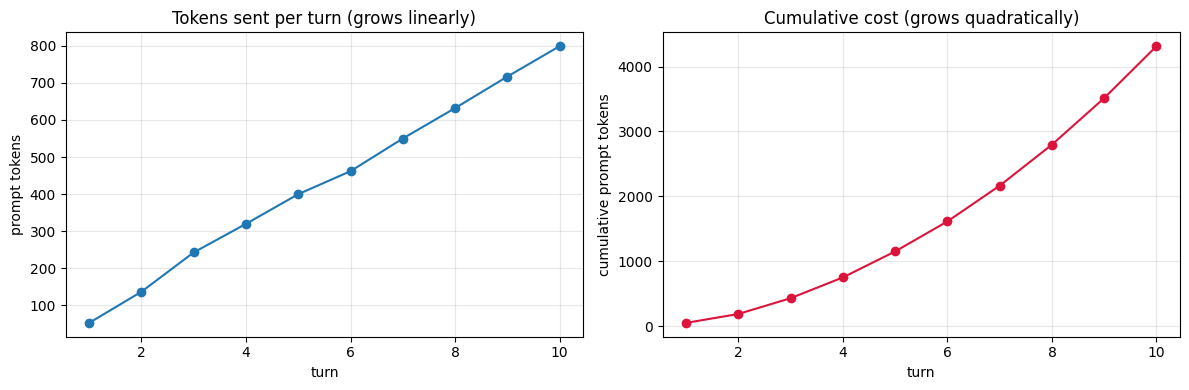

10턴 대화의 누적 입력 토큰: 4,313
만약 한 번만 보냈다면    : 799
배수                    : 5.4배


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["턴"], df["입력토큰"], "o-")
axes[0].set_xlabel("turn"); axes[0].set_ylabel("prompt tokens")
axes[0].set_title("Tokens sent per turn (grows linearly)")
axes[0].grid(alpha=0.3)

axes[1].plot(df["턴"], df["누적입력"], "o-", color="crimson")
axes[1].set_xlabel("turn"); axes[1].set_ylabel("cumulative prompt tokens")
axes[1].set_title("Cumulative cost (grows quadratically)")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"10턴 대화의 누적 입력 토큰: {df['누적입력'].iloc[-1]:,}")
print(f"만약 한 번만 보냈다면    : {df['입력토큰'].iloc[-1]:,}")
print(f"배수                    : {df['누적입력'].iloc[-1] / df['입력토큰'].iloc[-1]:.1f}배")

### 확인한 것 · What we confirmed

**한 턴에 보내는 양은 선형으로 늘고, 누적은 제곱으로 늘어납니다.**

10번째 턴에서 우리는 첫 메시지를 **열 번째로** 다시 보내고 있습니다.

이것이 영향을 주는 곳:
- **비용** — 상용 API라면 요금이 이렇게 붙습니다 (학과 서버는 무료지만)
- **속도** — 입력이 길수록 응답이 느려집니다
- **한계** — 언젠가 컨텍스트 윈도우에 부딪힙니다

6주차 ReAct 루프는 한 질문에 이런 호출을 10~20번 합니다.

> **EN — what you send per turn grows linearly; the cumulative total grows
> quadratically.** By the tenth turn we are transmitting the first message for
> the tenth time.
>
> Where that bites: **cost** (this is exactly how a commercial API bills you —
> our department server is free), **speed** (a longer input means a slower
> response), and **the limit** (eventually you hit the context window).
>
> The week-6 ReAct loop makes 10 to 20 such calls for a single question.

---
## 2. 토큰을 어떻게 셀 것인가 · How to count tokens

| 방법 | 정확도 | 비용 |
|---|---|---|
| 서버에 물어보기 (`usage`) | 정확 | **호출 1회** |
| 로컬 토크나이저 (`tiktoken`) | 모델이 다르면 부정확 | 무료 |
| 글자 수 기반 근사 | 대략 | 무료 |

**EN**

| Method | Accuracy | Cost |
|---|---|---|
| Ask the server (`usage`) | Exact | **One API call** |
| A local tokenizer (`tiktoken`) | Wrong if the model differs | Free |
| A character-count approximation | Roughly right | Free |

루프 안에서 예산을 확인하려고 호출을 한 번 더 하면 호출 수가 두 배가 됩니다.
그래서 **근사**를 씁니다. 대신 얼마나 틀리는지 알고 써야 합니다.

> **EN** — Making an extra call inside the loop just to check the budget doubles
> the number of calls, so we use **the approximation** — while knowing how far
> off it is.

In [ ]:
%%writefile memory.py
"""전산실험2 4주차 : 대화 상태와 메모리.

모델은 이전 대화를 기억하지 못한다. 기억은 **우리 코드가** 만든다.
그런데 대화를 통째로 다시 보내다 보면 컨텍스트 윈도우에 부딪힌다.

이 모듈은 세 가지를 제공한다.

    Conversation   대화 기록을 들고 있는 그릇 (system 은 항상 보존)
    예산 관리       토큰을 세고, 넘치면 오래된 턴을 잘라낸다
    요약 압축       잘라내는 대신 요약으로 갈아끼운다 (정보 손실 최소화)

EN — Week 4: conversation state and memory.
The model remembers nothing; OUR code creates the memory. But resending the
whole conversation eventually hits the context window. This module offers:
Conversation (a container for the history, with the system message always
preserved), budget management (count tokens and drop old turns when over), and
summary compression (replace old turns with a summary instead of dropping them).

사용 예 · Example:
    from kmu_llm import LLM
    from memory import Conversation

    llm = LLM()
    conv = Conversation(llm, system="너는 통계 조교다.", max_tokens=2000)
    print(conv.say("표준편차가 뭔가요?"))
    print(conv.say("그럼 표준오차는요?"))     # 앞 대화를 기억한다 / remembers
    conv.summary()                          # 현재 토큰 사용 현황 / token usage
"""

from __future__ import annotations

from typing import Any, Literal

__all__ = ["estimate_tokens", "Message", "Conversation"]

Role = Literal["system", "user", "assistant"]


# --------------------------------------------------------------------------
# 토큰 추정 / Token estimation
# --------------------------------------------------------------------------
def estimate_tokens(text: str) -> int:
    """토큰 수를 대략 추정한다. 서버에 묻지 않고 빠르게 계산한다.

    정확한 값은 모델의 토크나이저에 따라 다르다. 여기서는 경험적 근사를 쓴다.

        한글 1글자  ~ 1.2 토큰   (자소 단위로 잘게 쪼개짐)
        영문 1글자  ~ 0.3 토큰   (단어가 통째로 1토큰이 되는 경우가 많음)

    루프를 돌 때마다 서버에 물어보면 호출이 배로 늘어난다. 예산 관리는
    **근사로 충분**하고, 정확한 값이 필요하면 `LLM.count_tokens()` 를 쓴다.

    EN — Roughly estimate the token count locally, without asking the server.
    The exact number depends on the model's tokenizer; these are empirical
    approximations (one Hangul character ≈ 1.2 tokens because it splits into
    jamo; one Latin character ≈ 0.3 tokens because whole words often become one
    token). Asking the server on every loop iteration would double the number of
    calls — an approximation is good enough for budgeting, and `LLM.count_tokens()`
    is there when you need the exact figure.
    """
    if not text:
        return 0
    hangul = sum(1 for ch in text if "가" <= ch <= "힣")
    other = len(text) - hangul
    return int(hangul * 1.2 + other * 0.3) + 1


class Message(dict):
    """{"role": ..., "content": ...} 에 토큰 수를 얹은 것.

    EN — A {"role": ..., "content": ...} dict with a token count attached.
    """

    def __init__(self, role: Role, content: str) -> None:
        super().__init__(role=role, content=content)

    @property
    def tokens(self) -> int:
        return estimate_tokens(self["content"]) + 4  # 역할 표시 등 부대 비용 / overhead for the role marker

    def as_api(self) -> dict[str, str]:
        return {"role": self["role"], "content": self["content"]}


# --------------------------------------------------------------------------
# 대화 / Conversation
# --------------------------------------------------------------------------
class Conversation:
    """대화 기록을 관리하고 예산을 넘지 않게 유지한다.

    EN — Keeps the conversation history and holds it within the token budget.

    Parameters
    ----------
    llm : LLM 인스턴스 / an LLM instance
    system : 대화 전체에 적용되는 지시. **절대 잘려나가지 않는다.**
             EN — the instruction for the whole conversation; never truncated.
    max_tokens : 전체 대화의 토큰 예산 (응답 공간은 별도)
                 EN — token budget for the conversation (reply space is separate)
    strategy :
        "drop"    오래된 턴을 그냥 버린다 (빠르고 단순, 정보 손실)
                  EN — discard old turns (fast and simple, loses information)
        "summary" 오래된 턴을 요약으로 갈아끼운다 (호출 1회 추가, 손실 적음)
                  EN — replace old turns with a summary (one extra call, less loss)
        "none"    아무것도 하지 않는다 (한계를 직접 보고 싶을 때)
                  EN — do nothing, so you can watch the limit being hit
    keep_recent : 최근 몇 개의 메시지는 무조건 원본으로 보존할지
                  EN — how many recent messages are always kept verbatim
    """

    def __init__(
        self,
        llm: Any,
        system: str | None = None,
        *,
        max_tokens: int = 3000,
        strategy: str = "summary",
        keep_recent: int = 4,
    ) -> None:
        if strategy not in ("drop", "summary", "none"):
            raise ValueError(f"알 수 없는 strategy: {strategy!r}")

        self.llm = llm
        self.max_tokens = max_tokens
        self.strategy = strategy
        self.keep_recent = keep_recent

        self.system = Message("system", system) if system else None
        self.history: list[Message] = []
        self.compressions = 0          # 몇 번 압축했는지 / how many compressions so far
        self.dropped = 0               # 몇 개를 버렸는지 / how many messages were dropped

    # -- 상태 확인 / Inspecting the state ----------------------------------
    def messages(self) -> list[dict[str, str]]:
        """API 로 보낼 형태. / The shape that goes to the API."""
        head = [self.system] if self.system else []
        return [m.as_api() for m in head + self.history]

    @property
    def tokens(self) -> int:
        head = self.system.tokens if self.system else 0
        return head + sum(m.tokens for m in self.history)

    def summary(self) -> dict[str, Any]:
        """현재 상태를 한눈에. / The current state at a glance."""
        return {
            "메시지수": len(self.history) + (1 if self.system else 0),
            "추정토큰": self.tokens,
            "예산": self.max_tokens,
            "사용률": round(self.tokens / self.max_tokens, 3),
            "압축횟수": self.compressions,
            "버린메시지": self.dropped,
        }

    # -- 대화 / Talking ----------------------------------------------------
    def add(self, role: Role, content: str) -> None:
        self.history.append(Message(role, content))

    def say(self, text: str, **kw: Any) -> str:
        """사용자 발화를 넣고 모델의 답을 받아 기록에 남긴다.

        예산은 **보내기 전과 받은 뒤 두 번** 맞춘다. 그래야
        "대화는 항상 예산 안에 있다"는 불변식이 유지되어,
        지금 상태를 보고 다음 호출이 들어갈지 예측할 수 있다.

        EN — Append the user's utterance, get the model's reply, and record it.
        The budget is enforced twice — before sending and after receiving — so
        the invariant "the conversation always fits the budget" holds, which
        lets you predict from the current state whether the next call will fit.
        """
        self.add("user", text)
        self.fit()                                  # 보내기 전 / before sending
        reply = self.llm.chat(self.messages(), **kw)
        self.add("assistant", reply)
        self.fit()                                  # 받은 뒤 / after receiving
        return reply

    # -- 예산 관리 / Budget management -------------------------------------
    def fit(self) -> None:
        """예산을 넘으면 전략에 따라 줄인다.

        EN — Shrink the history according to the strategy when over budget.
        """
        if self.strategy == "none" or self.tokens <= self.max_tokens:
            return
        if self.strategy == "drop":
            self._drop_old()
        else:
            self._summarize_old()

    def _split(self) -> tuple[list[Message], list[Message]]:
        """(압축 대상인 오래된 것, 보존할 최근 것)

        EN — (the old part to compress, the recent part to keep)
        """
        if len(self.history) <= self.keep_recent:
            return [], self.history
        return self.history[: -self.keep_recent], self.history[-self.keep_recent :]

    def _drop_old(self) -> None:
        """가장 오래된 것부터 예산에 맞을 때까지 버린다.

        `keep_recent` 는 보존하려 하지만, 그것만으로도 예산을 넘으면
        보존 약속을 깨고 더 버린다. 마지막 메시지 하나는 남긴다 —
        그것이 사용자의 방금 질문이기 때문이다.

        EN — Drop from the oldest until the history fits. `keep_recent` is
        honoured where possible, but if even those exceed the budget the promise
        is broken and more is dropped. The last message always survives — it is
        the user's current question.
        """
        old, recent = self._split()
        while old and self.tokens > self.max_tokens:
            old.pop(0)
            self.dropped += 1
            self.history = old + recent
        self.history = old + recent

        # 최근 것만 남았는데도 넘치면, 보존 약속을 깨고 더 버린다
        # EN — if even the recent messages overflow, break the promise and drop more
        while len(self.history) > 1 and self.tokens > self.max_tokens:
            self.history.pop(0)
            self.dropped += 1

        if self.tokens > self.max_tokens:
            # 마지막 메시지 하나가 예산보다 크다. 내용을 몰래 자르지는 않는다.
            # 조용히 틀리느니 시끄럽게 알리는 편이 낫다. (3주차와 같은 원칙)
            # EN — a single message exceeds the budget. We do not silently
            #      truncate it: better to fail loudly than to be quietly wrong
            #      (the same principle as week 3).
            print(
                f"[경고] 마지막 메시지 하나가 예산({self.max_tokens} 토큰)을 "
                f"넘습니다 (현재 {self.tokens}). 예산을 늘리거나 입력을 줄이세요."
            )

    def _summarize_old(self) -> None:
        """오래된 대화를 요약 한 덩어리로 갈아끼운다.

        EN — Replace the old part of the conversation with a single summary.
        """
        old, recent = self._split()
        if not old:
            self._drop_old()          # 줄일 것이 최근 것뿐이면 버리는 수밖에 없다
                                      # EN — if only recent turns remain, dropping is the only option
            return

        기록 = "\n".join(f"[{m['role']}] {m['content']}" for m in old)
        지시 = (
            "다음은 사용자와 조수의 지난 대화다. 이후 대화를 이어가는 데 필요한 "
            "사실만 5문장 이내로 요약하라. 결정된 내용, 사용자가 밝힌 정보, "
            "아직 해결되지 않은 질문을 우선 남겨라. 인사말은 버려라.\n\n"
            f"{기록}"
        )
        try:
            요약 = self.llm.ask(지시, temperature=0.0, max_tokens=400)
        except Exception:
            self._drop_old()          # 요약 호출이 실패하면 버리기로 대체
                                      # EN — if the summary call fails, fall back to dropping
            return

        self.history = [Message("user", f"[이전 대화 요약]\n{요약}")] + recent
        self.compressions += 1

        if self.tokens > self.max_tokens:   # 요약해도 넘치면 결국 버린다 / still over: drop
            self._drop_old()

    # -- 저장 / 복원 · Saving and restoring --------------------------------
    def to_dict(self) -> dict[str, Any]:
        return {
            "system": self.system["content"] if self.system else None,
            "history": [m.as_api() for m in self.history],
            "compressions": self.compressions,
            "dropped": self.dropped,
        }

    @classmethod
    def from_dict(cls, llm: Any, data: dict[str, Any], **kw: Any) -> "Conversation":
        conv = cls(llm, system=data.get("system"), **kw)
        for m in data.get("history", []):
            conv.add(m["role"], m["content"])
        conv.compressions = data.get("compressions", 0)
        conv.dropped = data.get("dropped", 0)
        return conv


Writing memory.py


In [ ]:
from memory import estimate_tokens

표본 = [
    "표준편차",
    "표준편차는 자료가 평균에서 얼마나 흩어져 있는지를 나타내는 값입니다.",
    "standard deviation",
    "The standard deviation measures how spread out the data are from the mean.",
    "귀무가설 H0: mu1 = mu2, 대립가설 H1: mu1 != mu2, alpha = 0.05",
]

행 = []
for s in 표본:
    실제 = llm.count_tokens([{"role": "user", "content": s}])   # 서버에 물어본 값 / asked of the server
    근사 = estimate_tokens(s)                                    # 로컬 근사 / local approximation
    행.append({"텍스트": s[:38] + ("..." if len(s) > 38 else ""),
               "글자수": len(s), "근사": 근사, "실제(usage)": 실제,
               "오차율": round((근사 - 실제) / 실제, 2)})

pd.DataFrame(행)

,텍스트,글자수,근사,실제(usage),오차율
0,표준편차,4,5,13,-0.62
1,표준편차는 자료가 평균에서 얼마나 흩어져 있는지를 나타내는 값입니다.,38,39,29,0.34
2,standard deviation,18,6,11,-0.45
3,The standard deviation measures how sp...,74,23,23,0.00
4,"귀무가설 H0: mu1 = mu2, 대립가설 H1: mu1 != mu...",53,24,42,-0.43


> `실제(usage)` 에는 메시지 포장 비용(역할 표시 등)이 몇 토큰 섞여 있어
> 짧은 문장일수록 근사가 작게 나옵니다. 긴 문장에서 오차율을 보세요.
>
> **예산 관리에는 이 정도면 충분합니다.** 우리가 하려는 것은
> "이쯤에서 줄여야겠다"는 결정이지 정확한 회계가 아닙니다.
> 대신 근사가 틀릴 것을 감안해 **여유분**을 둡니다.

> **EN** — The `실제(usage)` column includes a few tokens of message packaging
> (role markers and so on), so the approximation reads low on short strings. Judge
> the error rate on the long ones.
>
> **This is good enough for budgeting.** The decision we are making is "time to
> trim", not exact accounting. We simply leave **slack** to cover the error.

---
## 3. 예산 세우기 · Setting the budget

```
대화에 쓸 예산 = 컨텍스트 윈도우 − 응답용 max_tokens − 여유분
conversation budget = context window − max_tokens for the reply − slack
```

컨텍스트 윈도우는 **입력만의 한도가 아니라 입력 + 출력의 한도**입니다.
이것을 놓치면 "요청은 통과했는데 답이 안 나오는" 증상을 만납니다.

> **EN** — The context window is **not a cap on input alone; it caps input plus
> output.** Miss that and you meet the symptom where "the request went through but
> no answer came back".

In [ ]:
# 이 서버의 한계는 어디쯤인가? 조심스럽게 탐색합니다.
# EN — Where is this server's limit? We probe carefully.
긴텍스트 = "통계적 가설검정의 절차는 다음과 같습니다. " * 200   # 약 8천 글자 / about 8,000 characters

for 배수 in [1, 2, 4, 8]:
    본문 = 긴텍스트 * 배수
    근사 = estimate_tokens(본문)
    try:
        r = llm.raw([{"role": "user", "content": 본문 + "\n\n한 단어로 답하세요: 위 내용의 주제는?"}],
                    max_tokens=20, temperature=0.0)
        답 = (r.choices[0].message.content or "").strip()
        print(f"근사 {근사:7,} 토큰  실제 {r.usage.prompt_tokens:7,}  ->  응답 {답[:30]!r}")
    except Exception as exc:
        print(f"근사 {근사:7,} 토큰  ->  실패: {type(exc).__name__}")
        print(f"    {str(exc)[:200]}")
        break

근사   4,681 토큰  실제   2,823  ->  응답 '가설검정'
근사   9,361 토큰  실제   5,623  ->  응답 '가설검정'
근사  18,721 토큰  실제  11,223  ->  응답 '가설검정'
근사  37,441 토큰  실제  22,423  ->  응답 '가설검정'


> 응답이 **빈 문자열**로 오면 그것도 신호입니다.
> 입력이 윈도우를 거의 채워서 응답이 들어갈 공간이 남지 않은 것입니다.
>
> 오류가 났다면 메시지를 잘 읽어 두세요.
> 서버마다 문구가 다르지만 대개 `context length` 라는 말이 들어 있습니다.

> **EN** — An **empty string** for a response is a signal too: the input has
> nearly filled the window, leaving no room for the answer.
>
> If you got an error, read the message carefully. The wording differs by server,
> but it usually contains the phrase `context length`.

---
## 연습문제 · Exercises

**문제 1.** `estimate_tokens()` 의 계수(한글 1.2, 영문 0.3)를 이 서버에 맞게
재추정하시오. 한글 문장 10개, 영문 문장 10개의 실제 `usage` 를 모아
회귀로 계수를 구하면 됩니다.

**문제 2.** 위 10턴 대화의 누적 입력 토큰이 턴 수의 **제곱**에 비례하는지
확인하시오. `누적 ~ a + b*턴 + c*턴^2` 으로 회귀해 `c` 가 유의한가?

**문제 3.** 같은 내용을 한국어와 영어로 각각 작성해 컨텍스트 효율을 비교하시오.
에이전트의 `system` 프롬프트를 영어로 쓰는 것이 유리할까? 장단점을 논하시오.

**문제 4.** 응답이 빈 문자열로 오는 경계를 이분탐색으로 찾으시오.
그 지점이 이 모델의 실질적 입력 한계다.

> **EN — 1.** Re-estimate the coefficients of `estimate_tokens()` (1.2 for
> Hangul, 0.3 for Latin) for this server: collect the real `usage` of ten Korean
> and ten English sentences and fit a regression.
>
> **EN — 2.** Check whether the cumulative input tokens of the ten-turn
> conversation above scale with the **square** of the turn number. Regress
> `cumulative ~ a + b·turn + c·turn²` — is `c` significant?
>
> **EN — 3.** Write the same content in Korean and in English and compare context
> efficiency. Would writing the agent's `system` prompt in English be an
> advantage? Argue both sides.
>
> **EN — 4.** Find, by binary search, the boundary at which the response comes
> back empty. That point is this model's practical input limit.

In [ ]:
# 여기에 직접 작성해 보세요 / Write your own code here

<details>
<summary><b>해설 보기 · Show the solutions</b></summary>

**문제 1.** 예시
```python
import numpy as np
from sklearn.linear_model import LinearRegression

행 = []
for s in 한글문장들 + 영문문장들:
    한 = sum(1 for ch in s if "가" <= ch <= "힣")
    행.append((한, len(s) - 한, llm.count_tokens([{"role":"user","content":s}])))
X = np.array([[a, b] for a, b, _ in 행]); y = np.array([t for _, _, t in 행])
m = LinearRegression().fit(X, y)
print("한글 계수:", m.coef_[0], "| 영문 계수:", m.coef_[1], "| 절편:", m.intercept_)
```
절편이 메시지 포장 비용에 해당합니다.

**문제 3.** 영어가 토큰 효율이 훨씬 좋습니다. 같은 내용이면 절반 이하인 경우도
많습니다. 그래서 실무에서 긴 `system` 프롬프트를 영어로 쓰기도 합니다.

다만 이 수업에서는 **한국어를 씁니다.** 이유는 두 가지입니다. 첫째, 프롬프트는
읽고 고쳐야 하는 코드이고, 읽기 쉬운 쪽이 유지보수에 유리합니다. 둘째, 소형
모델에서 한국어 지시를 주고 한국어 출력을 받는 편이 언어 전환으로 인한 혼란이
적습니다. **토큰 효율과 가독성의 교환**이며, 정답이 하나는 아닙니다.

---

**EN — 1.** Use the snippet above; the intercept corresponds to the message
packaging cost.

**EN — 3.** English is far more token-efficient — often less than half for the
same content, which is why long `system` prompts are sometimes written in English
in practice.

This course nonetheless **uses Korean**, for two reasons. First, a prompt is code
that has to be read and revised, and the readable version is the maintainable
one. Second, on a small model, giving Korean instructions and receiving Korean
output causes less language-switching confusion. It is **a trade between token
efficiency and readability**, and there is no single right answer.

</details>

---
## 정리 · Summary

- 대화를 매번 다시 보내므로 **누적 토큰은 제곱으로** 늘어난다
- 예산 = 윈도우 − 응답공간 − 여유분
- 토큰은 **근사로 충분**하다. 정확한 값은 `llm.count_tokens()`
- 응답이 빈 문자열이면 **응답 공간이 없다는 신호**

> **EN**
> - Because the conversation is resent every turn, **cumulative tokens grow
>   quadratically**
> - Budget = window − reply space − slack
> - **An approximation is enough** for tokens; use `llm.count_tokens()` when you
>   need the exact figure
> - An empty response is **the signal that there was no room to reply**

**다음 노트북** → [`02_conversation.ipynb`](https://colab.research.google.com/github/zoomer1975-boop/ai_agent/blob/main/week04/02_conversation.ipynb)